# NUTS-2 Regional Waste Hotspot Analysis

This notebook allocates national waste generation to NUTS-2 regions using SBS employment data as a proxy, then applies clustering to identify regional hotspots for waste recovery.

## Methodology
1. **Data sources**: 
   - Waste generation by country × NACE × waste type (Eurostat env_wasgen)
   - Employment by NUTS-2 region × NACE (Eurostat SBS sbs_r_nuts06_r2)
   - Recycling potential index by waste category

2. **Allocation approach**:
   - For each country-NACE combination, calculate regional employment shares
   - Allocate national waste to regions proportionally to employment
   - This assumes waste generation correlates with economic activity

3. **Analysis**:
   - Cluster regions by waste profile (not aggregated totals)
   - Calculate economic potential using recycling indices
   - Identify hotspots by region, NACE sector, and waste type

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
import eurostat
import warnings
warnings.filterwarnings('ignore')

pd.options.display.max_columns = 100
pd.options.display.max_rows = 100
plt.style.use('seaborn-v0_8-whitegrid')

/Users/jimanderssen/anaconda3/lib/python3.11/site-packages/pandas/core/arrays/masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


## 1. Load Data

In [2]:
# Load waste generation data (country × NACE × waste type)
wasgen = pd.read_csv('../data/interim/Generated_waste_per_nace_country.csv')
print(f"Waste generation records: {len(wasgen):,}")
wasgen.head()

Waste generation records: 38,834


,country,nace_r2,nace_r2_activity,waste,waste_description,2004,2006,2008,2010,2012,2014,2016,2018,2020,2022,mean_wasgen,std_wasgen
0,Germany,TOTAL_HH,All NACE activities plus households,TOTAL,Total waste,728044000.0,727572000.0,745593000.0,727090000.0,736044000.0,775008000.0,800143000.0,811047000.0,802313000.0,771590000.0,762444000.0,33959000.0
1,Germany,TOTAL_HH,All NACE activities plus households,PRIM,Primary waste (TOTAL minus SEC),0.0,0.0,0.0,661401000.0,659635000.0,693317000.0,715225000.0,723099000.0,710392000.0,680533000.0,691943000.0,25810000.0
2,France,TOTAL_HH,All NACE activities plus households,TOTAL,Total waste,593162000.0,624596000.0,690004000.0,710162000.0,688882000.0,648926000.0,640620000.0,682279000.0,614566000.0,686421000.0,657962000.0,39315000.0
3,France,TOTAL_HH,All NACE activities plus households,PRIM,Primary waste (TOTAL minus SEC),0.0,0.0,0.0,691647000.0,669317000.0,630886000.0,617862000.0,657957000.0,593657000.0,666824000.0,646878000.0,34222000.0
4,Germany,TOTAL_HH,All NACE activities plus households,W12-13,Mineral and solidified wastes (subtotal),540931000.0,544905000.0,547946000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,544594000.0,3629000.0


In [3]:
# Load SBS NUTS-2 employment data
# If not cached, fetch from Eurostat
try:
    sbs = pd.read_csv('../data/interim/sbs_nuts2_raw.csv')
    print("Loaded SBS data from cache")
except FileNotFoundError:
    print("Fetching SBS data from Eurostat...")
    sbs = eurostat.get_data_df('sbs_r_nuts06_r2', flags=False)
    sbs.to_csv('../data/interim/sbs_nuts2_raw.csv', index=False)

# Fix geo column name if needed
geo_col = [c for c in sbs.columns if 'geo' in c.lower()][0]
if geo_col != 'geo':
    sbs = sbs.rename(columns={geo_col: 'geo'})

print(f"SBS records: {len(sbs):,}")
print(f"Columns: {list(sbs.columns)}")

# Fetch NUTS2 region names from the geo dimension
print("\nFetching NUTS2 region names...")
geo_labels_df = eurostat.get_dic('sbs_r_nuts06_r2', 'geo', frmt='df')

# Filter to NUTS2 codes (4 characters, starting with letters)
geo_labels_df = geo_labels_df[
    (geo_labels_df['val'].str.len() == 4) & 
    (geo_labels_df['val'].str[:2].str.isalpha())
]

# Create lookup dictionary
nuts2_name_map = dict(zip(geo_labels_df['val'], geo_labels_df['descr']))

# Add derived columns to sbs
sbs['nuts2_name'] = sbs['geo'].map(nuts2_name_map)
sbs['country_code'] = sbs['geo'].str[:2]
sbs['is_nuts2'] = sbs['geo'].str.len() == 4

# Get employment values (most recent year with data)
year_cols = [c for c in sbs.columns if str(c).isdigit()]
sbs['employment'] = sbs[year_cols].bfill(axis=1).iloc[:, 0]

print(f"NUTS2 names loaded: {len(nuts2_name_map)}")

# Show a few examples
sample_regions = ['DE11', 'FR10', 'SE11', 'ES30', 'ITC4']
print("\nSample region names:")
for code in sample_regions:
    if code in nuts2_name_map:
        print(f"  {code}: {nuts2_name_map[code]}")

Loaded SBS data from cache
SBS records: 227,050
Columns: ['freq', 'nace_r2', 'indic_sb', 'geo', '2008', '2009', '2010', '2011', '2012', '2013', '2014', '2015', '2016', '2017', '2018', '2019', '2020']

Fetching NUTS2 region names...
NUTS2 names loaded: 659

Sample region names:
  DE11: Stuttgart
  FR10: Ile de France
  SE11: Stockholm
  ES30: Comunidad de Madrid
  ITC4: Lombardia


In [4]:
# Load recycling potential index
recyc_pot = pd.read_csv('../data/raw/EWC-recycling potential.csv', sep=';')
recyc_pot

,Category_Code,Description,Recycling_Potential_Index
0,01.1,Spent solvents,100
1,01.2,"Acid, alkaline or saline wastes (non-hazardous)",10
2,01.2*,"Acid, alkaline or saline wastes (hazardous)",1
3,01.3,Used oils (hazardous),100
4,01.4+02+03.1,Chemical wastes (non-hazardous),10
5,01.4+02+03.1*,Chemical wastes (hazardous),1
6,03.2,Industrial effluent sludges (non-hazardous),10
7,03.2*,Industrial effluent sludges (hazardous),1
8,03.3,Sludges and liquid wastes from waste treatment...,10
9,03.3*,Sludges and liquid wastes from waste treatment...,1


## 2. Prepare Waste Generation Data

In [5]:
# Country code mapping (ISO 2-letter)
country_map = {
    'Germany': 'DE', 'France': 'FR', 'Italy': 'IT', 'Spain': 'ES', 
    'Poland': 'PL', 'Netherlands': 'NL', 'Belgium': 'BE', 'Sweden': 'SE',
    'Austria': 'AT', 'Czechia': 'CZ', 'Portugal': 'PT', 'Greece': 'EL',
    'Hungary': 'HU', 'Denmark': 'DK', 'Finland': 'FI', 'Slovakia': 'SK',
    'Ireland': 'IE', 'Croatia': 'HR', 'Lithuania': 'LT', 'Slovenia': 'SI',
    'Latvia': 'LV', 'Estonia': 'EE', 'Cyprus': 'CY', 'Luxembourg': 'LU',
    'Malta': 'MT', 'Bulgaria': 'BG', 'Romania': 'RO', 'United Kingdom': 'UK',
    'Norway': 'NO', 'Iceland': 'IS', 'Türkiye': 'TR', 'Serbia': 'RS',
    'North Macedonia': 'MK', 'Montenegro': 'ME', 'Albania': 'AL',
    'Bosnia and Herzegovina': 'BA', 'Kosovo*': 'XK', 'Liechtenstein': 'LI'
}
wasgen['country_code'] = wasgen['country'].map(country_map)

In [6]:
# Filter to sector-specific waste (exclude totals and aggregates)
exclude_wastes = ['TOTAL', 'PRIM', 'SEC', 'TOT_X_MIN', 'W12-13']
exclude_nace = ['TOTAL_HH', 'EP_HH', 'HH']  # Keep sector-specific only

wasgen_detail = wasgen[
    (~wasgen['waste'].isin(exclude_wastes)) &
    (~wasgen['waste'].str.contains('X_', na=False)) &
    (~wasgen['nace_r2'].isin(exclude_nace)) &
    (wasgen['mean_wasgen'] > 0) &
    (wasgen['country_code'].notna())
].copy()

print(f"Filtered records: {len(wasgen_detail):,}")
print(f"Countries: {wasgen_detail['country_code'].nunique()}")
print(f"NACE activities: {wasgen_detail['nace_r2'].nunique()}")
print(f"Waste types: {wasgen_detail['waste'].nunique()}")

Filtered records: 16,408
Countries: 38
NACE activities: 20
Waste types: 43


In [7]:
# Show available NACE codes in waste data
print("NACE codes in waste data:")
for nace in sorted(wasgen_detail['nace_r2'].unique()):
    activity = wasgen_detail[wasgen_detail['nace_r2'] == nace]['nace_r2_activity'].iloc[0]
    print(f"  {nace}: {activity[:60]}")

NACE codes in waste data:
  A: Agriculture, forestry and fishing
  B: Mining and quarrying
  C: Manufacturing
  C10-C12: Manufacture of food products; beverages and tobacco products
  C13-C15: Manufacture of textiles, wearing apparel, leather and relate
  C16: Manufacture of wood and of products of wood and cork, except
  C17_C18: Manufacture of paper and paper products; printing and reprod
  C19: Manufacture of coke and refined petroleum products
  C20-C22: Manufacture of chemical, pharmaceutical, rubber and plastic 
  C23: Manufacture of other non-metallic mineral products
  C24_C25: Manufacture of basic metals and fabricated metal products, e
  C26-C30: Manufacture of computer, electronic and optical products, el
  C31-C33: Manufacture of furniture; jewellery, musical instruments, to
  D: Electricity, gas, steam and air conditioning supply
  E: Water supply; sewerage, waste management and remediation act
  E36_E37_E39: Water collection, treatment and supply; sewerage; remediatio
  E

In [8]:
# Show available waste types
print(f"\nWaste types ({wasgen_detail['waste'].nunique()}):")
waste_types = wasgen_detail[['waste', 'waste_description']].drop_duplicates().sort_values('waste')
for _, row in waste_types.iterrows():
    print(f"  {row['waste']}: {row['waste_description'][:55]}")


Waste types (43):
  W01-05: Chemical and medical wastes (subtotal)
  W011: Spent solvents
  W012: Acid, alkaline or saline wastes
  W013: Used oils
  W02A: Chemical wastes
  W032: Industrial effluent sludges
  W033: Sludges and liquid wastes from waste treatment
  W05: Health care and biological wastes
  W06: Metallic wastes (W061+W062+W063)
  W061: Metal wastes, ferrous
  W062: Metal wastes, non-ferrous
  W063: Metal wastes, mixed ferrous and non-ferrous
  W06_07A: Recyclable wastes (subtotal, W06+W07 except W077)
  W071: Glass wastes
  W072: Paper and cardboard wastes
  W073: Rubber wastes
  W074: Plastic wastes
  W075: Wood wastes
  W076: Textile wastes
  W077: Waste containing PCB
  W077_08: Equipment (subtotal, W077+W08A+W081+W0841)
  W081: Discarded vehicles
  W0841: Batteries and accumulators wastes
  W08A: Discarded equipment (except discarded vehicles and batt
  W09: Animal and vegetal wastes (subtotal, W091+W092+W093)
  W091: Animal and mixed food waste
  W091_092: Animal an

## 3. Build Allocation Keys from SBS Employment Data

In [9]:
# SBS indicators available
indic_map = {
    'V11210': 'Turnover (€ million)',
    'V13320': 'Value added (€ million)', 
    'V16110': 'Number of persons employed',
    'V91290': 'Wages and salaries (€ million)',
    'V94310': 'Number of local units'
}
print("SBS indicators:")
for code, desc in indic_map.items():
    print(f"  {code}: {desc}")

SBS indicators:
  V11210: Turnover (€ million)
  V13320: Value added (€ million)
  V16110: Number of persons employed
  V91290: Wages and salaries (€ million)
  V94310: Number of local units


In [10]:
# Filter to employment indicator (V16110) and NUTS-2 regions with data
sbs_nuts2 = sbs[
    (sbs['indic_sb'] == 'V16110') & 
    (sbs['is_nuts2']) & 
    (sbs['employment'] > 0)
].copy()

print(f"NUTS-2 employment records: {len(sbs_nuts2):,}")
print(f"Unique NUTS-2 regions: {sbs_nuts2['geo'].nunique()}")
print(f"Countries covered: {sbs_nuts2['country_code'].nunique()}")

NUTS-2 employment records: 34,189
Unique NUTS-2 regions: 371
Countries covered: 30


In [11]:
# NACE code mapping: waste data aggregates -> SBS detailed codes
nace_expansion = {
    'C24_C25': ['C24', 'C25'],
    'C10-C12': ['C10', 'C11', 'C12'],
    'C13-C15': ['C13', 'C14', 'C15'],
    'C17_C18': ['C17', 'C18'],
    'C20-C22': ['C20', 'C21', 'C22'],
    'C26-C30': ['C26', 'C27', 'C28', 'C29', 'C30'],
    'C31-C33': ['C31', 'C32', 'C33'],
    'C31_C32': ['C31', 'C32'],
    'D': ['D35'],
    'E': ['E36', 'E37', 'E38', 'E39'],
    'E36_E37_E39': ['E36', 'E37', 'E39'],
    'G-U_X_G4677': ['G', 'H', 'I', 'J', 'K', 'L', 'M', 'N'],
}

print("NACE expansion mapping:")
for agg, detailed in nace_expansion.items():
    print(f"  {agg} -> {detailed}")

NACE expansion mapping:
  C24_C25 -> ['C24', 'C25']
  C10-C12 -> ['C10', 'C11', 'C12']
  C13-C15 -> ['C13', 'C14', 'C15']
  C17_C18 -> ['C17', 'C18']
  C20-C22 -> ['C20', 'C21', 'C22']
  C26-C30 -> ['C26', 'C27', 'C28', 'C29', 'C30']
  C31-C33 -> ['C31', 'C32', 'C33']
  C31_C32 -> ['C31', 'C32']
  D -> ['D35']
  E -> ['E36', 'E37', 'E38', 'E39']
  E36_E37_E39 -> ['E36', 'E37', 'E39']
  G-U_X_G4677 -> ['G', 'H', 'I', 'J', 'K', 'L', 'M', 'N']


In [12]:
def get_regional_shares(sbs_data, country_code, nace_codes):
    """Calculate employment shares for a country and list of NACE codes."""
    regional = sbs_data[
        (sbs_data['country_code'] == country_code) &
        (sbs_data['nace_r2'].isin(nace_codes))
    ].groupby('geo')['employment'].sum().reset_index()
    
    total = regional['employment'].sum()
    if total > 0:
        regional['share'] = regional['employment'] / total
    else:
        regional['share'] = 0
    return regional

# Test the function
test = get_regional_shares(sbs_nuts2, 'DE', ['C24', 'C25'])
print(f"Example: Germany metal manufacturing (C24+C25) - {len(test)} NUTS-2 regions")
test.head(10)

Example: Germany metal manufacturing (C24+C25) - 42 NUTS-2 regions


,geo,employment,share
0,DE11,54462.0,0.056824
1,DE12,30785.0,0.032120
2,DE13,49547.0,0.051695
3,DE14,31905.0,0.033288
4,DE21,14773.0,0.015414
5,DE22,15921.0,0.016611
6,DE23,14673.0,0.015309
7,DE24,10868.0,0.011339
8,DE25,21647.0,0.022586
9,DE26,12339.0,0.012874


## 4. Allocate Waste to NUTS-2 Regions

In [13]:
# Allocate each waste record to NUTS-2 regions based on employment share
results = []
missing_nace = set()

for _, row in wasgen_detail.iterrows():
    country_code = row['country_code']
    nace_code = row['nace_r2']
    waste_type = row['waste']
    waste_desc = row['waste_description']
    nace_activity = row['nace_r2_activity']
    total_waste = row['mean_wasgen']
    
    # Expand NACE codes if aggregated
    sbs_nace_list = nace_expansion.get(nace_code, [nace_code])
    
    # Get regional employment shares
    regional_shares = get_regional_shares(sbs_nuts2, country_code, sbs_nace_list)
    
    if len(regional_shares) == 0 or regional_shares['share'].sum() == 0:
        missing_nace.add((country_code, nace_code))
        continue
    
    # Allocate waste to regions
    for _, reg in regional_shares.iterrows():
        allocated = total_waste * reg['share']
        if allocated > 0:
            # Look up NUTS2 region name
            nuts2_name = nuts2_name_map.get(reg['geo'], reg['geo'])
            results.append({
                'nuts2_region': reg['geo'],
                'nuts2_name': nuts2_name,
                'country_code': country_code,
                'nace_r2': nace_code,
                'nace_activity': nace_activity,
                'waste': waste_type,
                'waste_description': waste_desc,
                'allocated_waste_tonnes': allocated,
                'employment': reg['employment'],
                'allocation_share': reg['share']
            })

regional_waste = pd.DataFrame(results)
print(f"Allocated records: {len(regional_waste):,}")
print(f"Unique NUTS-2 regions: {regional_waste['nuts2_region'].nunique()}")
print(f"Missing NACE mappings: {len(missing_nace)}")

Allocated records: 192,047
Unique NUTS-2 regions: 371
Missing NACE mappings: 196


In [14]:
# View the allocated data
regional_waste.head(20)

,nuts2_region,nuts2_name,country_code,nace_r2,nace_activity,waste,waste_description,allocated_waste_tonnes,employment,allocation_share
0,RO11,Nord-Vest,RO,B,Mining and quarrying,W12A,"Mineral wastes (except combustion wastes, cont...",2.351971e+07,4452.0,0.053255
1,RO12,Centru,RO,B,Mining and quarrying,W12A,"Mineral wastes (except combustion wastes, cont...",5.016692e+07,9496.0,0.113593
2,RO21,Nord-Est,RO,B,Mining and quarrying,W12A,"Mineral wastes (except combustion wastes, cont...",3.910970e+07,7403.0,0.088556
3,RO22,Sud-Est,RO,B,Mining and quarrying,W12A,"Mineral wastes (except combustion wastes, cont...",2.566987e+07,4859.0,0.058124
4,RO31,Sud-Muntenia,RO,B,Mining and quarrying,W12A,"Mineral wastes (except combustion wastes, cont...",1.075662e+08,20361.0,0.243561
5,RO32,Bucureşti-Ilfov,RO,B,Mining and quarrying,W12A,"Mineral wastes (except combustion wastes, cont...",1.343455e+07,2543.0,0.030420
6,RO41,Sud-Vest Oltenia,RO,B,Mining and quarrying,W12A,"Mineral wastes (except combustion wastes, cont...",9.947272e+07,18829.0,0.225235
7,RO42,Vest,RO,B,Mining and quarrying,W12A,"Mineral wastes (except combustion wastes, cont...",8.269934e+07,15654.0,0.187256
8,FR10,Ile de France,FR,F,Construction,W12A,"Mineral wastes (except combustion wastes, cont...",4.721308e+07,328381.0,0.107903
9,FR21,Champagne-Ardenne (NUTS 2013),FR,F,Construction,W12A,"Mineral wastes (except combustion wastes, cont...",5.055428e+06,35162.0,0.011554


In [15]:
# Summary statistics
print(f"Total allocated waste: {regional_waste['allocated_waste_tonnes'].sum()/1e9:.2f} billion tonnes")
print(f"\nBy country:")
country_totals = regional_waste.groupby('country_code')['allocated_waste_tonnes'].sum().sort_values(ascending=False)
for country, total in country_totals.head(10).items():
    print(f"  {country}: {total/1e9:.2f}B tonnes")

Total allocated waste: 10.54 billion tonnes

By country:
  DE: 1.59B tonnes
  FR: 1.35B tonnes
  UK: 1.11B tonnes
  RO: 0.94B tonnes
  PL: 0.76B tonnes
  IT: 0.74B tonnes
  BG: 0.62B tonnes
  ES: 0.54B tonnes
  SE: 0.51B tonnes
  NL: 0.43B tonnes


## 5. Explore the Detailed Data (by Region × NACE × Waste)

In [16]:
# Top combinations by allocated waste (with descriptions)
print("Top 30 Region × NACE × Waste combinations by tonnage:")
top_combos = regional_waste.nlargest(30, 'allocated_waste_tonnes')[[
    'nuts2_region', 'nuts2_name', 'country_code', 'nace_r2', 'nace_activity', 
    'waste', 'waste_description', 'allocated_waste_tonnes'
]].copy()
top_combos['waste_Mt'] = top_combos['allocated_waste_tonnes'] / 1e6
top_combos[['nuts2_region', 'nuts2_name', 'nace_r2', 'waste', 'waste_Mt']]

Top 30 Region × NACE × Waste combinations by tonnage:


,nuts2_region,nuts2_name,nace_r2,waste,waste_Mt
231,SE33,Övre Norrland,B,W12B,140.621485
4,RO31,Sud-Muntenia,B,W12A,107.566201
174,BG41,Yugozapaden,B,W12A,106.206190
173,BG34,Yugoiztochen,B,W12A,101.251211
6,RO41,Sud-Vest Oltenia,B,W12A,99.472717
7,RO42,Vest,B,W12A,82.699342
180,BG41,Yugozapaden,B,W12B,80.410987
110,RO31,Sud-Muntenia,B,W12B,79.186673
179,BG34,Yugoiztochen,B,W12B,76.659467
330,PL22,Śląskie,B,W12B,74.862755


In [17]:
# Explore a specific region in detail
region_code = 'FR10'  # Île-de-France
region_data = regional_waste[regional_waste['nuts2_region'] == region_code]

print(f"\n{region_code} - Waste by NACE sector:")
by_nace = region_data.groupby(['nace_r2', 'nace_activity'])['allocated_waste_tonnes'].sum().sort_values(ascending=False)
for (nace, activity), tonnes in by_nace.head(10).items():
    print(f"  {nace}: {activity[:40]} - {tonnes/1e6:.1f}M tonnes")

print(f"\n{region_code} - Waste by type:")
by_waste = region_data.groupby(['waste', 'waste_description'])['allocated_waste_tonnes'].sum().sort_values(ascending=False)
for (waste, desc), tonnes in by_waste.head(10).items():
    print(f"  {waste}: {desc[:40]} - {tonnes/1e6:.1f}M tonnes")


FR10 - Waste by NACE sector:
  F: Construction - 100.6M tonnes
  G-U_X_G4677: Services (except wholesale of waste and  - 27.1M tonnes
  C: Manufacturing - 15.9M tonnes
  E: Water supply; sewerage, waste management - 10.4M tonnes
  E38: Waste collection, treatment and disposal - 8.0M tonnes
  E36_E37_E39: Water collection, treatment and supply;  - 6.2M tonnes
  C26-C30: Manufacture of computer, electronic and  - 3.9M tonnes
  D: Electricity, gas, steam and air conditio - 2.6M tonnes
  C24_C25: Manufacture of basic metals and fabricat - 2.5M tonnes
  C20-C22: Manufacture of chemical, pharmaceutical, - 2.3M tonnes

FR10 - Waste by type:
  W12A: Mineral wastes (except combustion wastes - 50.7M tonnes
  W126: Soils - 38.4M tonnes
  W06_07A: Recyclable wastes (subtotal, W06+W07 exc - 14.9M tonnes
  W121: Mineral waste from construction and demo - 14.2M tonnes
  W10: Mixed ordinary wastes (subtotal, W101+W1 - 8.9M tonnes
  W06: Metallic wastes (W061+W062+W063) - 7.0M tonnes
  W061: Metal was

In [18]:
# Explore a specific NACE sector across regions
nace_code = 'C24_C25'  # Metal manufacturing
nace_data = regional_waste[regional_waste['nace_r2'] == nace_code]

print(f"\nTop regions for {nace_code} (Basic metals & Fabricated metal products):")
by_region = nace_data.groupby('nuts2_region')['allocated_waste_tonnes'].sum().sort_values(ascending=False)
for region, tonnes in by_region.head(15).items():
    country = region[:2]
    print(f"  {region} ({country}): {tonnes/1e6:.2f}M tonnes")


Top regions for C24_C25 (Basic metals & Fabricated metal products):
  PL22 (PL): 14.98M tonnes
  ITC4 (IT): 9.57M tonnes
  PL41 (PL): 7.01M tonnes
  PL21 (PL): 6.89M tonnes
  PL12 (PL): 6.02M tonnes
  PL51 (PL): 5.71M tonnes
  PL82 (PL): 4.95M tonnes
  PL61 (PL): 4.46M tonnes
  DEA5 (DE): 4.43M tonnes
  ITD3 (IT): 4.28M tonnes
  ES51 (ES): 4.20M tonnes
  PL63 (PL): 4.14M tonnes
  PL71 (PL): 3.88M tonnes
  PL32 (PL): 3.85M tonnes
  ITH3 (IT): 3.78M tonnes


In [19]:
# Explore a specific waste type across regions
waste_code = 'W061'  # Ferrous metal wastes
waste_data = regional_waste[regional_waste['waste'] == waste_code]

print(f"\nTop regions for {waste_code} (Metallic wastes, ferrous):")
by_region = waste_data.groupby('nuts2_region')['allocated_waste_tonnes'].sum().sort_values(ascending=False)
for region, tonnes in by_region.head(15).items():
    country = region[:2]
    print(f"  {region} ({country}): {tonnes/1e6:.2f}M tonnes")


Top regions for W061 (Metallic wastes, ferrous):
  FR10 (FR): 7.00M tonnes
  ITC4 (IT): 4.06M tonnes
  DEG0 (DE): 3.56M tonnes
  ES51 (ES): 2.86M tonnes
  ES61 (ES): 2.48M tonnes
  PL22 (PL): 2.35M tonnes
  FRK2 (FR): 2.25M tonnes
  ES52 (ES): 2.18M tonnes
  ITD3 (IT): 2.14M tonnes
  FR71 (FR): 2.12M tonnes
  BE21 (BE): 2.03M tonnes
  ITH3 (IT): 1.94M tonnes
  ES30 (ES): 1.90M tonnes
  ITD5 (IT): 1.85M tonnes
  ITC1 (IT): 1.70M tonnes


## 6. Calculate Economic Potential

In [20]:
# Recycling potential index (€/tonne)
waste_value_map = {
    'W061': 1000,   # Ferrous metals
    'W062': 1000,   # Non-ferrous metals
    'W063': 500,    # Mixed metals
    'W06': 800,     # All metallic wastes
    'W071': 1000,   # Glass
    'W072': 1000,   # Paper/cardboard
    'W073': 100,    # Rubber
    'W074': 100,    # Plastics
    'W075': 100,    # Wood
    'W076': 10,     # Textiles
    'W077': 1,      # PCB wastes
    'W08A': 300,    # WEEE
    'W081': 500,    # Discarded vehicles
    'W091': 10,     # Animal food waste
    'W092': 100,    # Green waste
    'W093': 10,     # Slurry/manure
    'W101': 10,     # Mixed municipal
    'W102': 10,     # Mixed/undifferentiated
    'W103': 10,     # Sorting residues
    'W10': 10,      # Mixed wastes total
    'W11': 10,      # Sludges
    'W121': 100,    # Construction mineral
    'W124': 10,     # Combustion wastes
    'W126': 100,    # Soils
    'W127': 10,     # Dredging spoils
    'W12A': 50,     # Mineral wastes
    'W12B': 50,     # Other mineral
    'W128_13': 50,  # Mineral treatment
    'W13': 50,      # Solidified wastes
    'W01-05': 50,   # Chemical/medical
    'W011': 100,    # Spent solvents
    'W012': 10,     # Acid/alkaline
    'W013': 100,    # Used oils
    'W02A': 10,     # Chemical wastes
    'W032': 10,     # Industrial sludges
    'W033': 10,     # Sludges from treatment
    'W05': 1,       # Health care
    'W06_07A': 500, # Recyclables
}

# Add economic potential to regional waste data
regional_waste['recycling_potential_eur_t'] = regional_waste['waste'].map(waste_value_map).fillna(10)
regional_waste['economic_potential_eur'] = regional_waste['allocated_waste_tonnes'] * regional_waste['recycling_potential_eur_t']

print(f"Total economic potential: €{regional_waste['economic_potential_eur'].sum()/1e9:.1f} billion/year")

Total economic potential: €1358.6 billion/year


In [21]:
# Top combinations by economic potential (with descriptions)
print("Top 30 Region × NACE × Waste combinations by economic potential:")
top_econ = regional_waste.nlargest(30, 'economic_potential_eur')[[
    'nuts2_region', 'nuts2_name', 'country_code', 'nace_r2', 'nace_activity',
    'waste', 'waste_description', 'allocated_waste_tonnes', 
    'recycling_potential_eur_t', 'economic_potential_eur'
]].copy()
top_econ['waste_Mt'] = top_econ['allocated_waste_tonnes'] / 1e6
top_econ['econ_pot_M'] = top_econ['economic_potential_eur'] / 1e6
top_econ[['nuts2_region', 'nuts2_name', 'nace_r2', 'waste', 'waste_Mt', 'recycling_potential_eur_t', 'econ_pot_M']]

Top 30 Region × NACE × Waste combinations by economic potential:


,nuts2_region,nuts2_name,nace_r2,waste,waste_Mt,recycling_potential_eur_t,econ_pot_M
231,SE33,Övre Norrland,B,W12B,140.621485,50.0,7031.074236
4,RO31,Sud-Muntenia,B,W12A,107.566201,50.0,5378.310034
174,BG41,Yugozapaden,B,W12A,106.206190,50.0,5310.309494
3306,DEG0,Thüringen,E38,W06_07A,10.398000,500.0,5199.000000
173,BG34,Yugoiztochen,B,W12A,101.251211,50.0,5062.560566
6,RO41,Sud-Vest Oltenia,B,W12A,99.472717,50.0,4973.635855
7,RO42,Vest,B,W12A,82.699342,50.0,4134.967108
180,BG41,Yugozapaden,B,W12B,80.410987,50.0,4020.549373
110,RO31,Sud-Muntenia,B,W12B,79.186673,50.0,3959.333660
179,BG34,Yugoiztochen,B,W12B,76.659467,50.0,3832.973338


## 7. Create Pivot Tables for Analysis

In [22]:
# Region × Waste type matrix (with descriptions)
# Create lookup dictionaries for descriptions
waste_desc_map = regional_waste[['waste', 'waste_description']].drop_duplicates().set_index('waste')['waste_description'].to_dict()
nace_desc_map = regional_waste[['nace_r2', 'nace_activity']].drop_duplicates().set_index('nace_r2')['nace_activity'].to_dict()
nuts2_desc_map = regional_waste[['nuts2_region', 'nuts2_name']].drop_duplicates().set_index('nuts2_region')['nuts2_name'].to_dict()

# Region × Waste type matrix with MultiIndex columns (code + description)
region_waste_matrix = regional_waste.pivot_table(
    index='nuts2_region',
    columns='waste',
    values='allocated_waste_tonnes',
    aggfunc='sum'
).fillna(0)

# Add region names as additional column in index
region_waste_matrix['nuts2_name'] = region_waste_matrix.index.map(nuts2_desc_map)
region_waste_matrix = region_waste_matrix.reset_index().set_index(['nuts2_region', 'nuts2_name'])

# Rename columns to include descriptions
new_cols = {col: f"{col} - {waste_desc_map.get(col, '')[:40]}" for col in region_waste_matrix.columns if col in waste_desc_map}
region_waste_matrix = region_waste_matrix.rename(columns=new_cols)

print(f"Region × Waste matrix: {region_waste_matrix.shape}")
region_waste_matrix.head()

Region × Waste matrix: (371, 43)


,waste,W01-05 - Chemical and medical wastes (subtotal),W011 - Spent solvents,"W012 - Acid, alkaline or saline wastes",W013 - Used oils,W02A - Chemical wastes,W032 - Industrial effluent sludges,W033 - Sludges and liquid wastes from waste tre,W05 - Health care and biological wastes,W06 - Metallic wastes (W061+W062+W063),"W061 - Metal wastes, ferrous","W062 - Metal wastes, non-ferrous","W063 - Metal wastes, mixed ferrous and non-ferr","W06_07A - Recyclable wastes (subtotal, W06+W07 exc",W071 - Glass wastes,W072 - Paper and cardboard wastes,W073 - Rubber wastes,W074 - Plastic wastes,W075 - Wood wastes,W076 - Textile wastes,W077 - Waste containing PCB,"W077_08 - Equipment (subtotal, W077+W08A+W081+W084",W081 - Discarded vehicles,W0841 - Batteries and accumulators wastes,W08A - Discarded equipment (except discarded ve,"W09 - Animal and vegetal wastes (subtotal, W09",W091 - Animal and mixed food waste,W091_092 - Animal and mixed food waste; vegetal was,W092 - Vegetal wastes,"W093 - Animal faeces, urine and manure","W10 - Mixed ordinary wastes (subtotal, W101+W1",W101 - Household and similar wastes,W102 - Mixed and undifferentiated materials,W103 - Sorting residues,W11 - Common sludges,W121 - Mineral waste from construction and demo,W124 - Combustion wastes,W126 - Soils,"W126_127 - Soils and dredging spoils (W126+W127, va",W127 - Dredging spoils,W128_13 - Mineral wastes from waste treatment and,W12A - Mineral wastes (except combustion wastes,W12B - Other mineral wastes (W122+W123+W125),"W13 - Solidified, stabilised or vitrified wast"
nuts2_region,nuts2_name,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
AT11,Burgenland,80104.276163,3704.961252,15825.797028,3118.285466,31578.008859,5172.411515,11882.346558,2638.787097,90928.968841,1.563945e+05,25663.094047,0.0,7.618529e+05,6856.413753,65540.453566,3386.481055,23900.734978,2.277034e+05,6404.849551,0.0,10406.991625,3284.319361,1054.252066,2008.096696,2.084008e+05,37223.383315,2.082889e+05,33462.863431,180.852618,110439.643231,70064.416501,19271.030859,2.175872e+05,75547.914315,6.372259e+05,2.073808e+05,2.371871e+06,11394.824372,0.0,101990.724495,2.228604e+06,31442.801495,7777.441619
AT12,Niederösterreich,581969.037556,26542.884998,127522.192610,22530.053154,221820.617816,32811.538121,55536.989238,15998.868282,676548.146238,1.217705e+06,192286.363431,0.0,5.163959e+06,46342.077200,462178.792300,22812.768998,158716.281419,1.502288e+06,26899.148480,0.0,71181.220534,22320.594068,7169.895847,12901.465647,1.353497e+06,234712.103678,1.352706e+06,225475.000797,1283.398804,679940.457890,419932.961039,113195.846040,1.055336e+06,296762.648263,3.270002e+06,1.575327e+06,1.209710e+07,70502.467336,0.0,510807.771880,1.164800e+07,227767.536693,58953.537198
AT13,Wien,351950.870102,19477.099065,61886.328671,19626.932281,148383.975711,25622.491012,66506.573079,24045.675760,519974.040961,7.174473e+05,123726.715573,0.0,3.280088e+06,42299.052929,503299.896728,30415.937353,137337.651635,9.218057e+05,17947.868476,0.0,91009.637302,35394.610069,9686.799220,12926.705162,1.080669e+06,210769.970954,1.079352e+06,293850.646614,1947.335359,677321.888362,472981.469065,98461.902716,1.071153e+06,300348.497334,3.329783e+06,8.210493e+05,1.214804e+07,84770.471059,0.0,566749.773253,1.089764e+07,138721.705003,36935.326272
AT21,Kärnten,201352.447225,8637.414864,40770.691453,8030.005187,77799.446184,10694.118991,19845.700652,5771.928121,241864.763720,3.995364e+05,64597.254017,0.0,2.103562e+06,17506.015035,158970.791413,8128.370662,54030.618826,6.304811e+05,9126.842952,0.0,26643.902933,8105.455915,2655.542163,4824.126025,4.219311e+05,73865.776159,4.216373e+05,78140.201842,473.571637,238651.677897,149148.260183,40768.118530,3.064195e+05,100849.942667,1.302003e+06,4.921274e+05,4.834687e+06,26136.430429,0.0,166575.739748,4.631787e+06,76668.671488,20468.532981
AT22,Steiermark,536250.933380,19741.147624,127086.895710,21252.752931,196553.568016,28987.601261,47765.341110,12750.658545,682181.193921,1.199716e+06,191693.842219,0.0,5.000945e+06,3

In [23]:
# Region × NACE matrix (with descriptions)
region_nace_matrix = regional_waste.pivot_table(
    index='nuts2_region',
    columns='nace_r2',
    values='allocated_waste_tonnes',
    aggfunc='sum'
).fillna(0)

# Add region names as additional column in index
region_nace_matrix['nuts2_name'] = region_nace_matrix.index.map(nuts2_desc_map)
region_nace_matrix = region_nace_matrix.reset_index().set_index(['nuts2_region', 'nuts2_name'])

# Rename columns to include NACE descriptions
new_cols = {col: f"{col} - {nace_desc_map.get(col, '')[:40]}" for col in region_nace_matrix.columns if col in nace_desc_map}
region_nace_matrix = region_nace_matrix.rename(columns=new_cols)

print(f"Region × NACE matrix: {region_nace_matrix.shape}")
region_nace_matrix.head()

Region × NACE matrix: (371, 18)


,nace_r2,B - Mining and quarrying,C - Manufacturing,C10-C12 - Manufacture of food products; beverages,"C13-C15 - Manufacture of textiles, wearing apparel",C16 - Manufacture of wood and of products of w,C17_C18 - Manufacture of paper and paper products;,C19 - Manufacture of coke and refined petroleu,"C20-C22 - Manufacture of chemical, pharmaceutical,",C23 - Manufacture of other non-metallic minera,C24_C25 - Manufacture of basic metals and fabricat,"C26-C30 - Manufacture of computer, electronic and","C31-C33 - Manufacture of furniture; jewellery, mus","D - Electricity, gas, steam and air conditio","E - Water supply; sewerage, waste management","E36_E37_E39 - Water collection, treatment and supply;","E38 - Waste collection, treatment and disposal",F - Construction,G-U_X_G4677 - Services (except wholesale of waste and
nuts2_region,nuts2_name,,,,,,,,,,,,,,,,,,
AT11,Burgenland,67747.595229,9.104162e+05,2.477774e+05,23563.310660,2.838444e+05,87841.129744,0.000000,34528.945689,44776.130696,2.140073e+05,49108.259846,14319.869839,95696.865027,2.568009e+05,49490.238612,2.299411e+05,5.109575e+06,3.981302e+05
AT12,Niederösterreich,483977.683725,6.610892e+06,1.440578e+06,57810.807385,1.758490e+06,814078.729038,20146.304676,242256.930658,322677.352463,2.038784e+06,427373.610122,111902.786252,323258.682185,1.069954e+06,110711.496746,1.353817e+06,2.585747e+07,2.815165e+06
AT13,Wien,38050.019238,3.944459e+06,7.338388e+05,21110.144070,2.784635e+05,602501.676964,15589.743590,179665.999007,62438.687440,4.483653e+05,467602.316920,79609.762050,722337.150366,1.116890e+06,137350.686913,1.322921e+06,2.561879e+07,4.681423e+06
AT21,Kärnten,174009.234321,2.352158e+06,3.478895e+05,18011.407326,9.524258e+05,225985.525154,0.000000,67187.092314,180447.290254,5.231703e+05,232528.783480,33055.521660,243545.447719,3.204780e+05,43013.738250,3.646644e+05,1.036204e+07,1.044666e+06
AT22,Steiermark,341522.123894,6.390971e+06,8.817630e+05,65283.281930,1.793197e+06,768831.067961,0.000000,99221.639251,289366.390181,2.104947e+06,662050.090376,83422.249339,387910.418622,8.857987e+05,109489.515546,1.046891e+06,2.022926e+07,2.216050e+06


In [24]:
# Region × Waste economic potential matrix (with descriptions)
region_econ_matrix = regional_waste.pivot_table(
    index='nuts2_region',
    columns='waste',
    values='economic_potential_eur',
    aggfunc='sum'
).fillna(0)

# Add region names as additional column in index
region_econ_matrix['nuts2_name'] = region_econ_matrix.index.map(nuts2_desc_map)
region_econ_matrix = region_econ_matrix.reset_index().set_index(['nuts2_region', 'nuts2_name'])

# Rename columns to include waste descriptions
new_cols = {col: f"{col} - {waste_desc_map.get(col, '')[:40]}" for col in region_econ_matrix.columns if col in waste_desc_map}
region_econ_matrix = region_econ_matrix.rename(columns=new_cols)

print(f"Region × Waste economic potential matrix: {region_econ_matrix.shape}")

Region × Waste economic potential matrix: (371, 43)


## 8. Clustering by Region × NACE × Waste Profile

The goal is to identify hotspots at the granular level of **NUTS2 Region × NACE Activity × Waste Type**. This allows us to find specific industrial activities in specific regions that are hotspots for particular waste streams.

In [25]:
# Create the clustering dataset at Region × NACE × Waste level
# Each row is a unique combination, features include waste tonnage and economic potential

# Start from the detailed allocation data
cluster_source = regional_waste.copy()

# Create a unique identifier for each Region × NACE × Waste combination
cluster_source['combo_id'] = (cluster_source['nuts2_region'] + '_' + 
                              cluster_source['nace_r2'] + '_' + 
                              cluster_source['waste'])

# Aggregate if there are any duplicates (shouldn't be, but just in case)
cluster_base = cluster_source.groupby(['nuts2_region', 'nuts2_name', 'country_code', 
                                        'nace_r2', 'nace_activity', 
                                        'waste', 'waste_description']).agg({
    'allocated_waste_tonnes': 'sum',
    'economic_potential_eur': 'sum',
    'recycling_potential_eur_t': 'first'
}).reset_index()

print(f"Total Region × NACE × Waste combinations: {len(cluster_base):,}")
print(f"Unique regions: {cluster_base['nuts2_region'].nunique()}")
print(f"Unique NACE activities: {cluster_base['nace_r2'].nunique()}")
print(f"Unique waste types: {cluster_base['waste'].nunique()}")

Total Region × NACE × Waste combinations: 192,047
Unique regions: 371
Unique NACE activities: 18
Unique waste types: 43


In [26]:
# Create features for clustering
# We'll use: log-transformed waste tonnage, economic potential, and categorical encodings

# Log-transform to handle skewed distributions
cluster_base['log_waste'] = np.log10(cluster_base['allocated_waste_tonnes'] + 1)
cluster_base['log_econ'] = np.log10(cluster_base['economic_potential_eur'] + 1)

# One-hot encode NACE and waste categories for clustering
from sklearn.preprocessing import LabelEncoder

# Create label encoders for categorical variables
le_nace = LabelEncoder()
le_waste = LabelEncoder()
le_region = LabelEncoder()

cluster_base['nace_encoded'] = le_nace.fit_transform(cluster_base['nace_r2'])
cluster_base['waste_encoded'] = le_waste.fit_transform(cluster_base['waste'])
cluster_base['region_encoded'] = le_region.fit_transform(cluster_base['nuts2_region'])

# Features for clustering: continuous + categorical info
# Option 1: Cluster on continuous values only (waste amount, economic potential)
# Option 2: Include categorical encodings to group similar activities together

# We'll use continuous features for primary clustering
features_for_clustering = ['log_waste', 'log_econ', 'recycling_potential_eur_t']
X_cluster = cluster_base[features_for_clustering].values

# Standardize
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)

print(f"Clustering features: {features_for_clustering}")
print(f"Data shape: {X_scaled.shape}")

Clustering features: ['log_waste', 'log_econ', 'recycling_potential_eur_t']
Data shape: (192047, 3)


Best k by silhouette: 3 (score: 0.474)


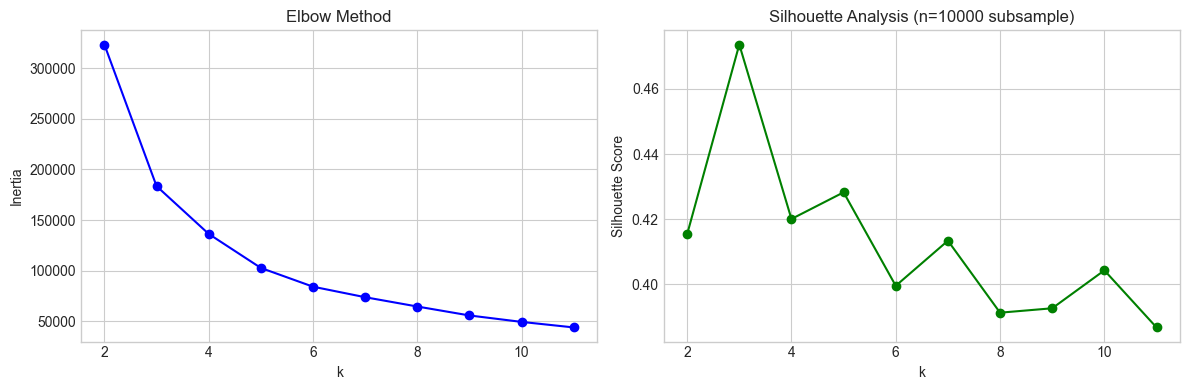

In [27]:
# Find optimal number of clusters (using subsample for speed)
k_range = range(2, 12)
silhouettes = []
inertias = []

# Subsample for faster silhouette calculation (192k rows is too slow)
sample_size = 10000
np.random.seed(42)
sample_idx = np.random.choice(len(X_scaled), size=min(sample_size, len(X_scaled)), replace=False)
X_sample = X_scaled[sample_idx]

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)  # Fit on full data
    inertias.append(km.inertia_)
    # Calculate silhouette on subsample only
    sample_labels = km.predict(X_sample)
    silhouettes.append(silhouette_score(X_sample, sample_labels))

# Plot
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(list(k_range), inertias, 'bo-')
axes[0].set_xlabel('k')
axes[0].set_ylabel('Inertia')
axes[0].set_title('Elbow Method')

axes[1].plot(list(k_range), silhouettes, 'go-')
axes[1].set_xlabel('k')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title(f'Silhouette Analysis (n={sample_size} subsample)')

best_k = list(k_range)[np.argmax(silhouettes)]
print(f"Best k by silhouette: {best_k} (score: {max(silhouettes):.3f})")
plt.tight_layout()
plt.show()

In [28]:
# Apply clustering - using 5 clusters to identify hotspot tiers
# Cluster 0: Low volume, low value (background)
# Higher clusters: Increasingly significant hotspots

n_clusters = 5  # Adjust based on silhouette or domain knowledge

kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
cluster_base['cluster'] = kmeans.fit_predict(X_scaled)

# Sort clusters by mean economic potential (so higher cluster = higher value)
cluster_means = cluster_base.groupby('cluster')['economic_potential_eur'].mean().sort_values()
cluster_rank_map = {old: new for new, old in enumerate(cluster_means.index)}
cluster_base['cluster'] = cluster_base['cluster'].map(cluster_rank_map)

print(f"Cluster distribution (sorted by economic potential):")
for c in range(n_clusters):
    subset = cluster_base[cluster_base['cluster'] == c]
    print(f"  Cluster {c}: {len(subset):,} combinations, "
          f"avg €{subset['economic_potential_eur'].mean()/1e6:.1f}M, "
          f"avg {subset['allocated_waste_tonnes'].mean()/1e3:.1f}k tonnes")

Cluster distribution (sorted by economic potential):
  Cluster 0: 45,823 combinations, avg €0.0M, avg 0.1k tonnes
  Cluster 1: 65,902 combinations, avg €0.1M, avg 1.8k tonnes
  Cluster 2: 19,294 combinations, avg €0.4M, avg 0.5k tonnes
  Cluster 3: 41,192 combinations, avg €11.7M, avg 222.6k tonnes
  Cluster 4: 19,836 combinations, avg €43.7M, avg 62.6k tonnes


In [29]:
# PCA for visualization of the Region × NACE × Waste combinations
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

cluster_base['pc1'] = X_pca[:, 0]
cluster_base['pc2'] = X_pca[:, 1]

print(f"PCA explained variance: PC1={pca.explained_variance_ratio_[0]:.1%}, PC2={pca.explained_variance_ratio_[1]:.1%}")

# Show PCA loadings - how each feature contributes to the principal components
loadings = pd.DataFrame(
    pca.components_.T,
    columns=['PC1', 'PC2'],
    index=features_for_clustering
)
print("\nPCA Loadings (feature contributions):")
print(loadings.round(3))

# Show top hotspots (highest cluster, sorted by economic potential)
top_cluster = n_clusters - 1
top_hotspots = cluster_base[cluster_base['cluster'] == top_cluster].nlargest(30, 'economic_potential_eur')

print(f"\nTop 30 Hotspots (Cluster {top_cluster} - Highest Value):")
print("-" * 100)
for i, (_, row) in enumerate(top_hotspots.iterrows(), 1):
    print(f"{i:2}. {row['nuts2_region']} | {row['nace_r2']:12} | {row['waste']:6} | "
          f"{row['allocated_waste_tonnes']/1e6:6.2f}M t | €{row['economic_potential_eur']/1e9:5.2f}B")
    print(f"    {row['nuts2_name'][:35]} | {row['nace_activity'][:30]} | {row['waste_description'][:30]}")

PCA explained variance: PC1=66.7%, PC2=32.0%

PCA Loadings (feature contributions):
                             PC1    PC2
log_waste                  0.617 -0.481
log_econ                   0.700 -0.025
recycling_potential_eur_t  0.359  0.876

Top 30 Hotspots (Cluster 4 - Highest Value):
----------------------------------------------------------------------------------------------------
 1. DEG0 | E38          | W06_07A |  10.40M t | € 5.20B
    Thüringen | Waste collection, treatment an | Recyclable wastes (subtotal, W
 2. FR10 | G-U_X_G4677  | W06_07A |   6.70M t | € 3.35B
    Ile de France | Services (except wholesale of  | Recyclable wastes (subtotal, W
 3. FI18 | C            | W06_07A |   6.35M t | € 3.17B
    Etelä-Suomi (NUTS 2006) | Manufacturing | Recyclable wastes (subtotal, W
 4. FR10 | G-U_X_G4677  | W06    |   3.87M t | € 3.09B
    Ile de France | Services (except wholesale of  | Metallic wastes (W061+W062+W06
 5. DEG0 | E38          | W06    |   3.10M t | € 2.48B
    Th

## 9. Visualize Hotspot Clusters (Region × NACE × Waste)

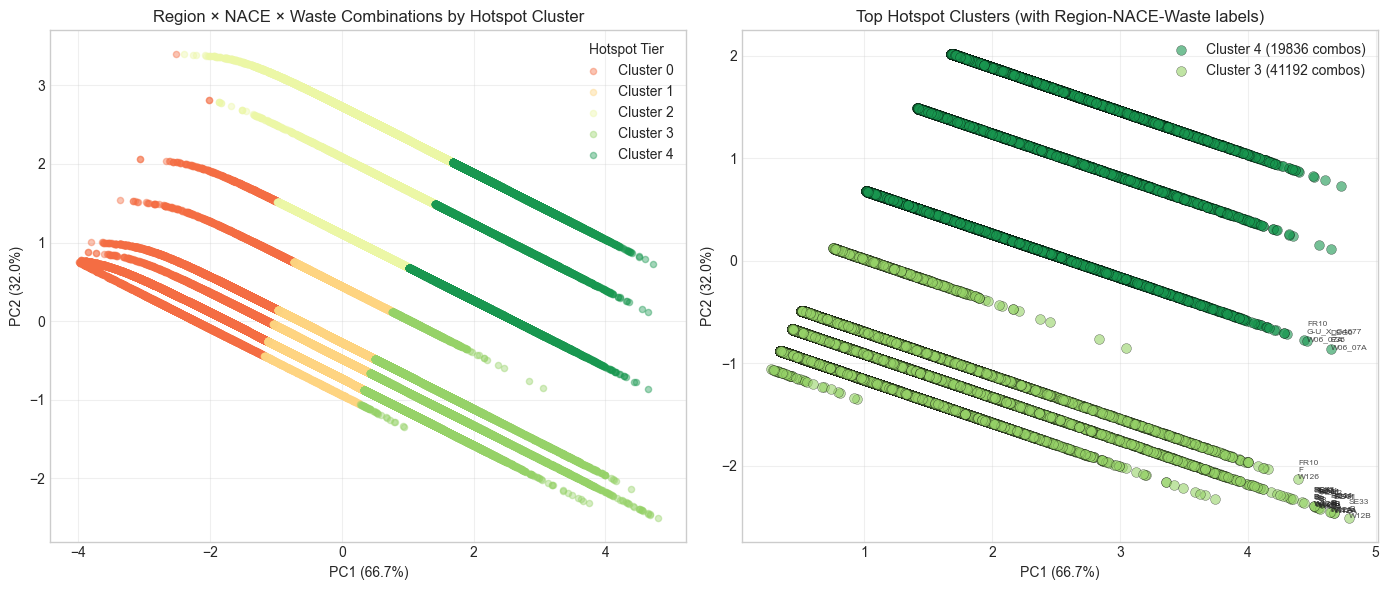

In [30]:
# PCA scatter plot of Region × NACE × Waste combinations
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

colors = plt.cm.RdYlGn(np.linspace(0.2, 0.9, n_clusters))  # Green=high value, Red=low

# Plot 1: All combinations colored by cluster
for c in range(n_clusters):
    mask = cluster_base['cluster'] == c
    axes[0].scatter(cluster_base[mask]['pc1'], cluster_base[mask]['pc2'],
                    c=[colors[c]], s=20, alpha=0.4, label=f'Cluster {c}')

axes[0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')
axes[0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')
axes[0].set_title('Region × NACE × Waste Combinations by Hotspot Cluster')
axes[0].legend(title='Hotspot Tier')
axes[0].grid(True, alpha=0.3)

# Plot 2: Focus on top clusters with labels
top_clusters = [n_clusters-1, n_clusters-2]  # Top 2 clusters
for c in top_clusters:
    mask = cluster_base['cluster'] == c
    subset = cluster_base[mask]
    axes[1].scatter(subset['pc1'], subset['pc2'],
                    c=[colors[c]], s=50, alpha=0.6, 
                    label=f'Cluster {c} ({len(subset)} combos)', edgecolors='black', linewidths=0.3)

# Annotate top 15 hotspots
top_15 = cluster_base.nlargest(15, 'economic_potential_eur')
for _, row in top_15.iterrows():
    label = f"{row['nuts2_region']}\n{row['nace_r2']}\n{row['waste']}"
    axes[1].annotate(label, (row['pc1'], row['pc2']), fontsize=6, alpha=0.8)

axes[1].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')
axes[1].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')
axes[1].set_title('Top Hotspot Clusters (with Region-NACE-Waste labels)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('nuts2_clustering_results.png', dpi=150, bbox_inches='tight')
plt.show()

In [31]:
# Aggregate view: Top regions by number of high-value hotspots
top_cluster_threshold = n_clusters - 2  # Clusters 3 and 4 are "high value"

high_value_combos = cluster_base[cluster_base['cluster'] >= top_cluster_threshold]

# Count hotspots per region
region_hotspot_count = high_value_combos.groupby(['nuts2_region', 'nuts2_name', 'country_code']).agg({
    'nace_r2': 'nunique',  # Number of different NACE activities
    'waste': 'nunique',     # Number of different waste types
    'allocated_waste_tonnes': 'sum',
    'economic_potential_eur': 'sum',
    'cluster': 'count'      # Total number of hotspot combinations
}).rename(columns={
    'nace_r2': 'n_nace_activities',
    'waste': 'n_waste_types',
    'cluster': 'n_hotspot_combos'
}).reset_index().sort_values('economic_potential_eur', ascending=False)

print(f"Regions with high-value hotspots (clusters >= {top_cluster_threshold}):")
print(f"Total regions: {len(region_hotspot_count)}")
print(f"\nTop 20 regions by economic potential from hotspots:")
print("-" * 90)
for i, (_, r) in enumerate(region_hotspot_count.head(20).iterrows(), 1):
    print(f"{i:2}. {r['nuts2_region']} - {r['nuts2_name'][:30]} ({r['country_code']})")
    print(f"    {r['n_hotspot_combos']} hotspots across {r['n_nace_activities']} NACE × {r['n_waste_types']} waste types | €{r['economic_potential_eur']/1e9:.2f}B")

Regions with high-value hotspots (clusters >= 3):
Total regions: 368

Top 20 regions by economic potential from hotspots:
------------------------------------------------------------------------------------------
 1. FR10 - Ile de France (FR)
    355 hotspots across 18 NACE × 42 waste types | €34.20B
 2. DEG0 - Thüringen (DE)
    301 hotspots across 17 NACE × 41 waste types | €24.12B
 3. ITC4 - Lombardia (IT)
    355 hotspots across 18 NACE × 41 waste types | €18.43B
 4. ES51 - Cataluña (ES)
    326 hotspots across 18 NACE × 42 waste types | €15.40B
 5. PL22 - Śląskie (PL)
    275 hotspots across 18 NACE × 36 waste types | €14.14B
 6. FR71 - Rhône-Alpes (NUTS 2013) (FR)
    255 hotspots across 17 NACE × 42 waste types | €13.15B
 7. RO31 - Sud-Muntenia (RO)
    193 hotspots across 18 NACE × 33 waste types | €13.12B
 8. FRK2 - Rhône-Alpes (FR)
    250 hotspots across 17 NACE × 42 waste types | €12.79B
 9. SE33 - Övre Norrland (SE)
    152 hotspots across 16 NACE × 36 waste types | €12.45

## 10. Cluster Profiles by Region × NACE × Waste

In [32]:
# Detailed profile of each cluster
for c in range(n_clusters):
    subset = cluster_base[cluster_base['cluster'] == c]
    
    print(f"\n{'='*70}")
    print(f"CLUSTER {c}: {len(subset):,} Region × NACE × Waste combinations")
    print(f"{'='*70}")
    
    # Summary stats
    print(f"Total waste: {subset['allocated_waste_tonnes'].sum()/1e9:.2f}B tonnes")
    print(f"Total economic potential: €{subset['economic_potential_eur'].sum()/1e9:.1f}B")
    print(f"Avg waste per combo: {subset['allocated_waste_tonnes'].mean()/1e3:.1f}k tonnes")
    print(f"Avg economic value per combo: €{subset['economic_potential_eur'].mean()/1e6:.2f}M")
    
    # Top regions in this cluster
    top_regions = subset.groupby('nuts2_region')['economic_potential_eur'].sum().nlargest(5)
    print(f"\nTop 5 regions:")
    for region, value in top_regions.items():
        print(f"  {region}: €{value/1e9:.2f}B")
    
    # Top NACE activities in this cluster
    top_nace = subset.groupby('nace_r2')['economic_potential_eur'].sum().nlargest(5)
    print(f"\nTop 5 NACE activities:")
    for nace, value in top_nace.items():
        activity = subset[subset['nace_r2'] == nace]['nace_activity'].iloc[0]
        print(f"  {nace}: €{value/1e9:.2f}B - {activity[:40]}")
    
    # Top waste types in this cluster
    top_waste = subset.groupby('waste')['economic_potential_eur'].sum().nlargest(5)
    print(f"\nTop 5 waste types:")
    for waste, value in top_waste.items():
        desc = subset[subset['waste'] == waste]['waste_description'].iloc[0]
        print(f"  {waste}: €{value/1e9:.2f}B - {desc[:40]}")
    
    # Example hotspots from this cluster
    print(f"\nExample hotspots:")
    for _, row in subset.nlargest(3, 'economic_potential_eur').iterrows():
        print(f"  {row['nuts2_region']} | {row['nace_r2']} | {row['waste']} | €{row['economic_potential_eur']/1e6:.1f}M")


CLUSTER 0: 45,823 Region × NACE × Waste combinations
Total waste: 0.00B tonnes
Total economic potential: €0.1B
Avg waste per combo: 0.1k tonnes
Avg economic value per combo: €0.00M

Top 5 regions:
  ITC2: €0.00B
  ITH1: €0.00B
  ITF5: €0.00B
  ITD1: €0.00B
  ES23: €0.00B

Top 5 NACE activities:
  B: €0.01B - Mining and quarrying
  C23: €0.01B - Manufacture of other non-metallic minera
  C31-C33: €0.01B - Manufacture of furniture; jewellery, mus
  C16: €0.01B - Manufacture of wood and of products of w
  C17_C18: €0.01B - Manufacture of paper and paper products;

Top 5 waste types:
  W08A: €0.01B - Discarded equipment (except discarded ve
  W013: €0.01B - Used oils
  W011: €0.01B - Spent solvents
  W073: €0.01B - Rubber wastes
  W126: €0.00B - Soils

Example hotspots:
  NL23 | D | W08A | €0.0M
  UKI6 | C24_C25 | W08A | €0.0M
  ITH4 | C17_C18 | W08A | €0.0M

CLUSTER 1: 65,902 Region × NACE × Waste combinations
Total waste: 0.12B tonnes
Total economic potential: €3.6B
Avg waste per combo:

## 11. Drill-Down: Specific Waste Streams

In [33]:
# Focus on high-value waste streams: metals
metal_wastes = ['W061', 'W062', 'W063', 'W06']
metals_data = regional_waste[regional_waste['waste'].isin(metal_wastes)]

metals_by_region = metals_data.groupby(['nuts2_region', 'nuts2_name', 'country_code']).agg({
    'allocated_waste_tonnes': 'sum',
    'economic_potential_eur': 'sum'
}).reset_index().sort_values('economic_potential_eur', ascending=False)

print("Top 20 regions for METAL WASTES:")
for i, (_, r) in enumerate(metals_by_region.head(20).iterrows(), 1):
    print(f"  {i:2}. {r['nuts2_region']} - {r['nuts2_name'][:30]} ({r['country_code']}): {r['allocated_waste_tonnes']/1e6:.2f}M t, €{r['economic_potential_eur']/1e9:.2f}B")

Top 20 regions for METAL WASTES:
   1. FR10 - Ile de France (FR): 15.58M t, €13.74B
   2. ITC4 - Lombardia (IT): 9.45M t, €8.43B
   3. DEG0 - Thüringen (DE): 8.41M t, €7.68B
   4. ES51 - Cataluña (ES): 6.65M t, €5.82B
   5. FRK2 - Rhône-Alpes (FR): 5.12M t, €4.49B
   6. FR71 - Rhône-Alpes (NUTS 2013) (FR): 5.01M t, €4.37B
   7. ITD3 - Veneto (NUTS 2006) (IT): 4.86M t, €4.34B
   8. BE21 - Prov. Antwerpen (BE): 4.75M t, €4.20B
   9. ES61 - Andalucía (ES): 4.46M t, €4.05B
  10. ITH3 - Veneto (IT): 4.40M t, €3.94B
  11. PL22 - Śląskie (PL): 4.12M t, €3.78B
  12. ITD5 - Emilia-Romagna (NUTS 2006) (IT): 4.21M t, €3.76B
  13. ES52 - Comunitat Valenciana (ES): 4.17M t, €3.75B
  14. ITC1 - Piemonte (IT): 3.85M t, €3.45B
  15. ES30 - Comunidad de Madrid (ES): 3.79M t, €3.39B
  16. PT11 - Norte (PT): 3.76M t, €3.32B
  17. ITH5 - Emilia-Romagna (IT): 3.69M t, €3.29B
  18. SE23 - Västsverige (SE): 3.75M t, €3.16B
  19. BE32 - Prov. Hainaut (BE): 3.25M t, €2.89B
  20. UKI2 - Outer London (NUTS 2010)

In [34]:
# Focus on recyclables
recyclable_wastes = ['W071', 'W072', 'W074', 'W075']  # Glass, Paper, Plastics, Wood
recyclables_data = regional_waste[regional_waste['waste'].isin(recyclable_wastes)]

recyclables_by_region = recyclables_data.groupby(['nuts2_region', 'nuts2_name', 'country_code']).agg({
    'allocated_waste_tonnes': 'sum',
    'economic_potential_eur': 'sum'
}).reset_index().sort_values('economic_potential_eur', ascending=False)

print("Top 20 regions for RECYCLABLES (Glass, Paper, Plastics, Wood):")
for i, (_, r) in enumerate(recyclables_by_region.head(20).iterrows(), 1):
    print(f"  {i:2}. {r['nuts2_region']} - {r['nuts2_name'][:30]} ({r['country_code']}): {r['allocated_waste_tonnes']/1e6:.2f}M t, €{r['economic_potential_eur']/1e9:.2f}B")

Top 20 regions for RECYCLABLES (Glass, Paper, Plastics, Wood):
   1. FR10 - Ile de France (FR): 7.16M t, €3.91B
   2. BE21 - Prov. Antwerpen (BE): 5.11M t, €3.03B
   3. DEG0 - Thüringen (DE): 18.27M t, €2.92B
   4. ES51 - Cataluña (ES): 3.47M t, €2.17B
   5. BE32 - Prov. Hainaut (BE): 3.20M t, €1.97B
   6. UKI1 - Inner London (NUTS 2010) (UK): 2.77M t, €1.94B
   7. ITC4 - Lombardia (IT): 4.54M t, €1.94B
   8. BE23 - Prov. Oost-Vlaanderen (BE): 3.31M t, €1.88B
   9. BE25 - Prov. West-Vlaanderen (BE): 3.54M t, €1.85B
  10. UKI2 - Outer London (NUTS 2010) (UK): 2.80M t, €1.83B
  11. ES30 - Comunidad de Madrid (ES): 2.43M t, €1.59B
  12. PT11 - Norte (PT): 2.78M t, €1.46B
  13. FR71 - Rhône-Alpes (NUTS 2013) (FR): 2.86M t, €1.35B
  14. ES61 - Andalucía (ES): 2.16M t, €1.32B
  15. BE33 - Prov. Liège (BE): 2.28M t, €1.32B
  16. FRK2 - Rhône-Alpes (FR): 2.76M t, €1.31B
  17. UKD3 - Greater Manchester (NUTS 2021) (UK): 2.07M t, €1.31B
  18. UKM3 - South Western Scotland (NUTS 2 (UK): 2.06M t, 

In [35]:
# Focus on construction waste
construction_wastes = ['W121', 'W126', 'W12A', 'W12B']
construction_data = regional_waste[regional_waste['waste'].isin(construction_wastes)]

construction_by_region = construction_data.groupby(['nuts2_region', 'nuts2_name', 'country_code']).agg({
    'allocated_waste_tonnes': 'sum',
    'economic_potential_eur': 'sum'
}).reset_index().sort_values('allocated_waste_tonnes', ascending=False)

print("Top 20 regions for CONSTRUCTION/MINERAL WASTES:")
for i, (_, r) in enumerate(construction_by_region.head(20).iterrows(), 1):
    print(f"  {i:2}. {r['nuts2_region']} - {r['nuts2_name'][:30]} ({r['country_code']}): {r['allocated_waste_tonnes']/1e6:.2f}M t, €{r['economic_potential_eur']/1e6:.0f}M")

Top 20 regions for CONSTRUCTION/MINERAL WASTES:
   1. SE33 - Övre Norrland (SE): 215.80M t, €10840M
   2. RO31 - Sud-Muntenia (RO): 194.31M t, €9746M
   3. BG41 - Yugozapaden (BG): 193.05M t, €9684M
   4. RO41 - Sud-Vest Oltenia (RO): 183.89M t, €9214M
   5. BG34 - Yugoiztochen (BG): 180.46M t, €9037M
   6. RO42 - Vest (RO): 151.39M t, €7593M
   7. PL22 - Śląskie (PL): 146.23M t, €7559M
   8. BG42 - Yuzhen tsentralen (BG): 107.61M t, €5395M
   9. FR10 - Ile de France (FR): 105.54M t, €7907M
  10. RO12 - Centru (RO): 99.29M t, €4993M
  11. FI1D - Pohjois- ja Itä-Suomi (FI): 78.07M t, €4176M
  12. RO21 - Nord-Est (RO): 75.79M t, €3813M
  13. DE40 - Brandenburg (DE): 68.38M t, €5004M
  14. FI18 - Etelä-Suomi (NUTS 2006) (FI): 60.58M t, €3566M
  15. FR71 - Rhône-Alpes (NUTS 2013) (FR): 56.86M t, €4259M
  16. RO22 - Sud-Est (RO): 55.28M t, €2791M
  17. DEA1 - Düsseldorf (DE): 53.56M t, €3584M
  18. FRK2 - Rhône-Alpes (FR): 52.24M t, €3916M
  19. RO11 - Nord-Vest (RO): 48.63M t, €2459M
  20.

## 12. Export Results

In [36]:
# Save detailed allocation data with cluster assignments
cluster_base_export = cluster_base[[
    'nuts2_region', 'nuts2_name', 'country_code',
    'nace_r2', 'nace_activity',
    'waste', 'waste_description',
    'allocated_waste_tonnes', 'recycling_potential_eur_t', 'economic_potential_eur',
    'cluster'
]].copy()

cluster_base_export.to_csv('../data/processed/nuts2_waste_allocated_detail.csv', index=False)
print(f"Saved: data/processed/nuts2_waste_allocated_detail.csv ({len(cluster_base_export):,} records)")

# Save summary by region (aggregated from detailed data)
region_summary = cluster_base.groupby(['nuts2_region', 'nuts2_name', 'country_code']).agg({
    'allocated_waste_tonnes': 'sum',
    'economic_potential_eur': 'sum',
    'nace_r2': 'nunique',
    'waste': 'nunique',
    'cluster': lambda x: (x >= top_cluster_threshold).sum()  # Count of high-value hotspots
}).rename(columns={
    'nace_r2': 'n_nace_activities',
    'waste': 'n_waste_types',
    'cluster': 'n_high_value_hotspots'
}).reset_index()

# Add the dominant cluster for each region
dominant_cluster = cluster_base.groupby('nuts2_region')['cluster'].agg(
    lambda x: x.value_counts().index[0]
).rename('dominant_cluster')
region_summary = region_summary.merge(dominant_cluster, on='nuts2_region')

region_summary = region_summary.sort_values('economic_potential_eur', ascending=False)
region_summary.to_csv('../data/processed/nuts2_regional_hotspots.csv', index=False)
print(f"Saved: data/processed/nuts2_regional_hotspots.csv ({len(region_summary):,} regions)")

# Save pivot tables
region_waste_matrix.to_csv('../data/processed/nuts2_region_waste_matrix.csv')
region_nace_matrix.to_csv('../data/processed/nuts2_region_nace_matrix.csv')
print(f"Saved pivot matrices")

Saved: data/processed/nuts2_waste_allocated_detail.csv (192,047 records)
Saved: data/processed/nuts2_regional_hotspots.csv (371 regions)
Saved pivot matrices


In [37]:
# Summary statistics
print("\n" + "="*70)
print("ANALYSIS SUMMARY - Region × NACE × Waste Hotspot Clustering")
print("="*70)
print(f"Total Region × NACE × Waste combinations analyzed: {len(cluster_base):,}")
print(f"  - NUTS-2 regions: {cluster_base['nuts2_region'].nunique()}")
print(f"  - NACE activities: {cluster_base['nace_r2'].nunique()}")
print(f"  - Waste types: {cluster_base['waste'].nunique()}")
print(f"\nTotal waste allocated: {cluster_base['allocated_waste_tonnes'].sum()/1e9:.2f} billion tonnes")
print(f"Total economic potential: €{cluster_base['economic_potential_eur'].sum()/1e9:.1f} billion/year")

print(f"\nCluster distribution:")
for c in range(n_clusters):
    subset = cluster_base[cluster_base['cluster'] == c]
    print(f"  Cluster {c}: {len(subset):,} combos ({len(subset)/len(cluster_base)*100:.1f}%) - €{subset['economic_potential_eur'].sum()/1e9:.1f}B")

print(f"\nTop 10 Hotspots (Region × NACE × Waste):")
for i, (_, r) in enumerate(cluster_base.nlargest(10, 'economic_potential_eur').iterrows(), 1):
    print(f"  {i:2}. {r['nuts2_region']} | {r['nace_r2']} | {r['waste']} | €{r['economic_potential_eur']/1e9:.2f}B")
    print(f"      {r['nuts2_name'][:25]} | {r['nace_activity'][:25]} | {r['waste_description'][:25]}")


ANALYSIS SUMMARY - Region × NACE × Waste Hotspot Clustering
Total Region × NACE × Waste combinations analyzed: 192,047
  - NUTS-2 regions: 371
  - NACE activities: 18
  - Waste types: 43

Total waste allocated: 10.54 billion tonnes
Total economic potential: €1358.6 billion/year

Cluster distribution:
  Cluster 0: 45,823 combos (23.9%) - €0.1B
  Cluster 1: 65,902 combos (34.3%) - €3.6B
  Cluster 2: 19,294 combos (10.0%) - €7.2B
  Cluster 3: 41,192 combos (21.4%) - €481.8B
  Cluster 4: 19,836 combos (10.3%) - €865.9B

Top 10 Hotspots (Region × NACE × Waste):
   1. SE33 | B | W12B | €7.03B
      Övre Norrland | Mining and quarrying | Other mineral wastes (W12
   2. RO31 | B | W12A | €5.38B
      Sud-Muntenia | Mining and quarrying | Mineral wastes (except co
   3. BG41 | B | W12A | €5.31B
      Yugozapaden | Mining and quarrying | Mineral wastes (except co
   4. DEG0 | E38 | W06_07A | €5.20B
      Thüringen | Waste collection, treatme | Recyclable wastes (subtot
   5. BG34 | B | W12A | €